In [1]:
import sys
from collections import defaultdict

import json

import numpy as np
import pandas as pd
import scipy.stats as ss
import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
cell_type_mapper = {
    'c1': 'MDA-MB-231',
    'c2': 'HepG2',
    'c4': 'Jurkat',
    'c6': 'SW480',
    'c13': 'PA-1',
    'c17': 'NALM6'
}

## Loading data

In [4]:
with open("utr5_ablation_stepwise.joint.json", "rt") as handle:
    ablation_utr5 = json.load(handle)
with open("utr3_ablation_stepwise.joint.json", "rt") as handle:
    ablation_utr3 = json.load(handle)

In [5]:
ablation_utr5_df = pd.DataFrame([k for j in ablation_utr5 for k in j])
ablation_utr3_df = pd.DataFrame([k for j in ablation_utr3 for k in j])

In [6]:
ablation_utr5_df['utr'] = ablation_utr5_df['model'].str[:4]
ablation_utr5_df['model'] = ablation_utr5_df['model'].str[5:]
ablation_utr3_df['utr'] = ablation_utr3_df['model'].str[:4]
ablation_utr3_df['model'] = ablation_utr3_df['model'].str[5:]

/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 40.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


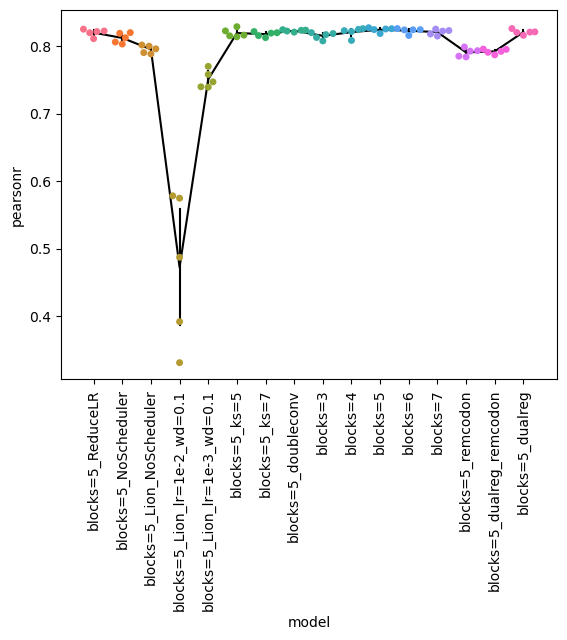

In [7]:
subdf_u5 = ablation_utr5_df[
    (ablation_utr5_df['model'] != 'utr5_blocks=5_Lion_lr=1e-2_wd=0.1')
    & (ablation_utr5_df['cell type'] == 'all')
]
sns.swarmplot(subdf_u5, x='model', y='pearsonr', hue='model')
sns.lineplot(subdf_u5, x='model', y='pearsonr', color='k', err_style='bars')
plt.gca().tick_params(axis='x', rotation=90)

/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)
/home/arsen_l/.miniconda3/envs/ml/lib/python3.11/site-packages/seaborn/categorical.py:3399: UserWarning: 20.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.
  warnings.warn(msg, UserWarning)


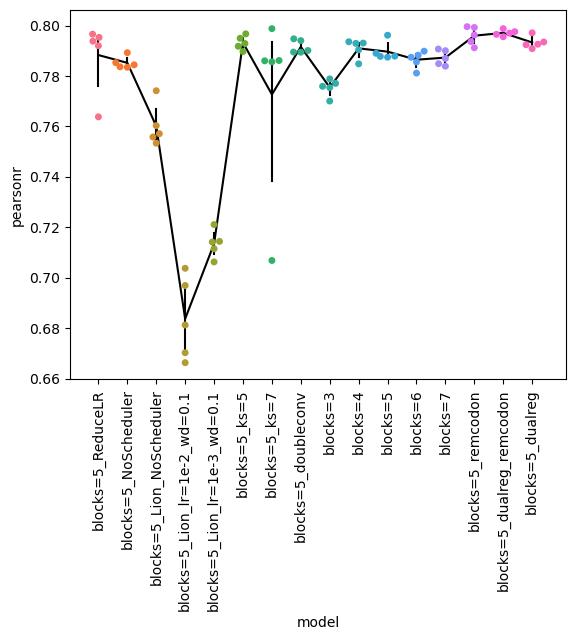

In [8]:
subdf_u3 = ablation_utr3_df[
    (ablation_utr3_df['model'] != 'utr3_blocks=5_Lion_lr=1e-2_wd=0.1')
    & (ablation_utr3_df['cell type'] == 'all')
]
sns.swarmplot(subdf_u3, x='model', y='pearsonr', hue='model')
sns.lineplot(subdf_u3, x='model', y='pearsonr', color='k', err_style='bars')
plt.gca().tick_params(axis='x', rotation=90)

In [9]:
out = pd.concat([
    ablation_utr5_df.groupby(['utr', 'model', 'cell type'])[['pearsonr']].agg(('mean', 'std')),
    ablation_utr3_df.groupby(['utr', 'model', 'cell type'])[['pearsonr']].agg(('mean', 'std')),
], axis=0).unstack(-1)
out.to_csv('all_ablation.csv')

In [10]:
out

pearsonr                                \
                                       mean                                 
cell type                               all        c1       c13       c17   
utr  model                                                                  
utr3 blocks=3                      0.775452  0.729572  0.634132  0.689471   
     blocks=4                      0.790951  0.734680  0.652749  0.716751   
     blocks=5                      0.789648  0.734401  0.652296  0.717472   
     blocks=5_Lion_NoScheduler     0.760139  0.718106  0.610252  0.692829   
     blocks=5_Lion_lr=1e-2_wd=0.1  0.683684  0.680922  0.492031  0.585127   
     blocks=5_Lion_lr=1e-3_wd=0.1  0.713474  0.697687  0.545282  0.622693   
     blocks=5_NoScheduler          0.785208  0.733274  0.640372  0.711401   
     blocks=5_ReduceLR             0.788294  0.734361  0.649471  0.711154   
     blocks=5_doubleconv           0.791558  0.734968  0.655106  0.719930   
     blocks=5_dualreg              0.793283  0.742764  0.654486  0.719126   
     blocks=5_dualreg_remcodon     0.797084  0.744372  0.657319  0.723474   
     blocks=5_ks=5                 0.793205  0.741852  0.657539  0.720398   
     blocks=5_ks=7                 0.772674  0.729147  0.634681  0.693441   
     blocks=5_remcodon             0.795983  0.739032  0.660832  0.722942   
     blocks=6                      0.786447  0.731720  0.643671  0.714144   
     blocks=7                      0.787291  0.732642  0.647924  0.711513   
utr5 blocks=3                      0.815639  0.767583       NaN  0.729199   
     blocks=4                      0.821144  0.774933       NaN  0.739088   
     blocks=5                      0.824725  0.778724       NaN  0.747020   
     blocks=5_Lion_NoScheduler     0.795665  0.729864       NaN  0.720064   
     blocks=5_Lion_lr=1e-2_wd=0.1  0.472807  0.431513       NaN  0.372346   
     blocks=5_Lion_lr=1e-3_wd=0.1  0.751184  0.682839       NaN  0.649377   
     blocks=5_NoScheduler          0.812524  0.763335       NaN  0.739679   
     blocks=5_ReduceLR             0.820388  0.775837       NaN  0.742195   
     blocks=5_doubleconv           0.823327  0.778073       NaN  0.746515   
     blocks=5_dualreg              0.821209  0.774033       NaN  0.742528   
     blocks=5_dualreg_remcodon     0.792591  0.736512       NaN  0.728634   
     blocks=5_ks=5                 0.819760  0.771385       NaN  0.741308   
     blocks=5_ks=7                 0.818159  0.769877       NaN  0.740131   
     blocks=5_remcodon             0.791121  0.737053       NaN  0.724510   
     blocks=6                      0.823285  0.775684       NaN  0.748476   
     blocks=7                      0.821095  0.775549       NaN  0.744733   

                                                                           \
                                                                      std   
cell type                                c2        c4        c6       all   
utr  model                                                                  
utr3 blocks=3                      0.734872  0.618831  0.712216  0.003294   
     blocks=4                      0.746805  0.646811  0.728231  0.003650   
     blocks=5                      0.745881  0.645398  0.727244  0.003688   
     blocks=5_Lion_NoScheduler     0.718689  0.610812  0.700029  0.008221   
     blocks=5_Lion_lr=1e-2_wd=0.1  0.656434  0.512849  0.607948  0.016325   
     blocks=5_Lion_lr=1e-3_wd=0.1  0.686362  0.542796  0.632778  0.005366   
     blocks=5_NoScheduler          0.742610  0.634410  0.720788  0.002366   
     blocks=5_ReduceLR             0.745167  0.639513  0.720999  0.013806   
     blocks=5_doubleconv           0.746971  0.649674  0.727967  0.002605   
     blocks=5_dualreg              0.749136  0.649439  0.728481  0.002340   
     blocks=5_dualreg_remcodon     0.753617  0.653418  0.732166  0.001197   
     blocks=5_ks=5                 0.749333  0.647697  0.728473  0.002727   
     blocks=5_ks=7            